In [1]:
import numpy as np
import matplotlib.pyplot as plt

def impseq(n0, n1, n2):
# Genera x(n) = delta(n-n0); n1 <= n <= n2
# ----------------------------------------------
  n = np.arange(n1,n2+1) # Se crea el vector de muestras
  x = ((n-n0) == 0).astype(int) # el astype conviernte los booleanos en números
  return [x,n]


# **Practica 2: Laboratorio de Bioseñales**

Luisa Fernanda LLamas

Camila Montiel




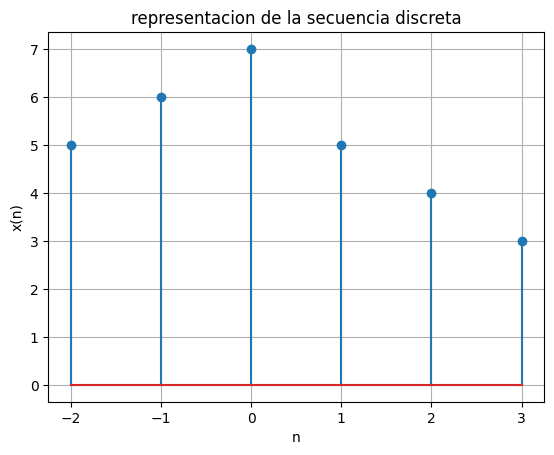

In [10]:
n = np.array([-2,-1,0,1,2,3])
x = np.array([5,6,7,5,4,3])
#graficamos la señal discreta
plt.stem(n, x)
plt.xlabel("n")
plt.ylabel("x(n)")
plt.title("representacion de la secuencia discreta")
plt.grid(True)


In [11]:
def impulso_unitario (n0,n1, n2):
    n = np.arange(n1, n2 + 1)
    x = ( n == n0 ).astype(int)  # Crea un impulso unitario
    return x , n

def escalon_unitario (n0,n1, n2):
    n = np.arange(n1, n2 + 1)
    x = ( n >= n0 ).astype(int)  # Crea un escalón unitario
    return x , n
def rampa_unitario (n0,n1, n2):
    n = np.arange(n1, n2 + 1)
    x = ( n >= n0 ) * (n - n0)  # Crea una rampa unitario
    return x , n

In [12]:
def graficar_señal(x, n, titulo):
    plt.stem(n, x)
    plt.xlabel("n")
    plt.ylabel("x(n)")
    plt.title(titulo)
    plt.grid(True)
    plt.show()

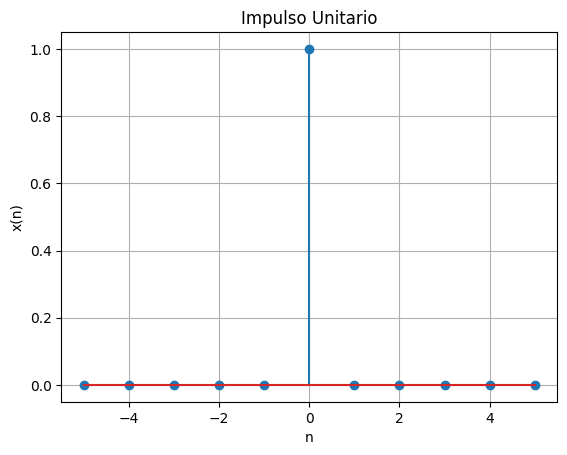

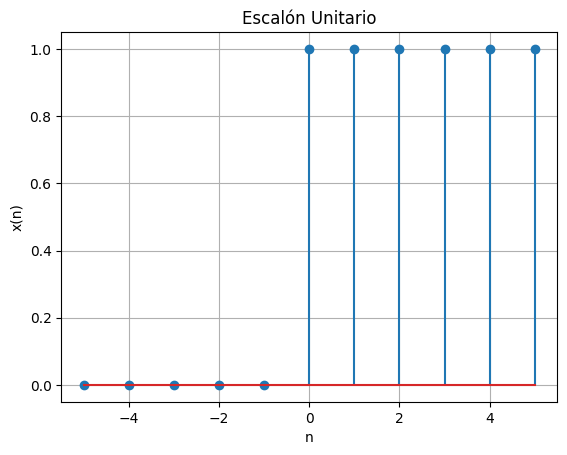

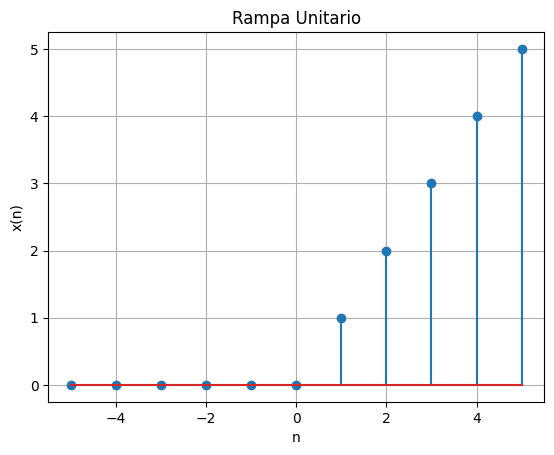

In [13]:
graficar_señal(*impulso_unitario(0, -5, 5), "Impulso Unitario")
graficar_señal(*escalon_unitario(0, -5, 5), "Escalón Unitario")
graficar_señal(*rampa_unitario(0, -5, 5), "Rampa Unitario") 

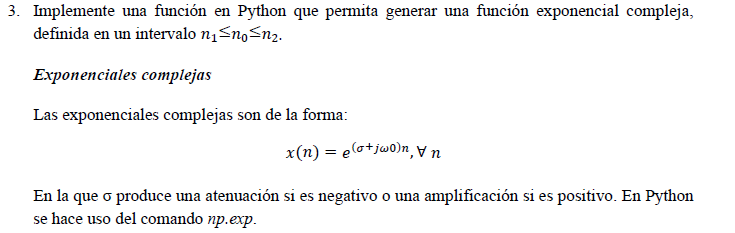

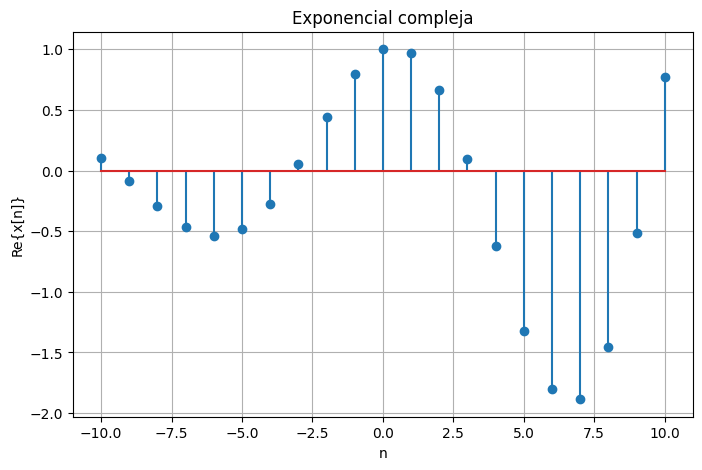

In [15]:

# Función exponencial compleja
def exp_compleja(n1, n2, sigma, w0):
    
    n = np.arange(n1, n2+1)      # vector de muestras
    
    x = np.exp((sigma + 1j*w0) * n)   # exponencial compleja
    
    return x, n


# Generar la señal
x, n = exp_compleja(-10, 10, 0.1, 0.5)


# Graficar (parte real)
plt.figure(figsize=(8,5))
plt.stem(n, np.real(x))
plt.title("Exponencial compleja")
plt.xlabel("n")
plt.ylabel("Re{x[n]}")
plt.grid(True)
plt.show()


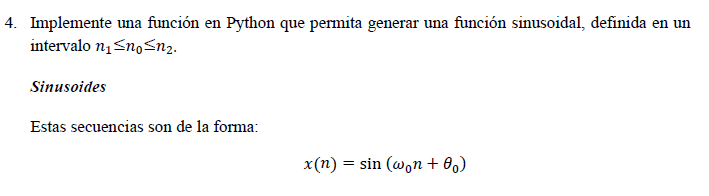

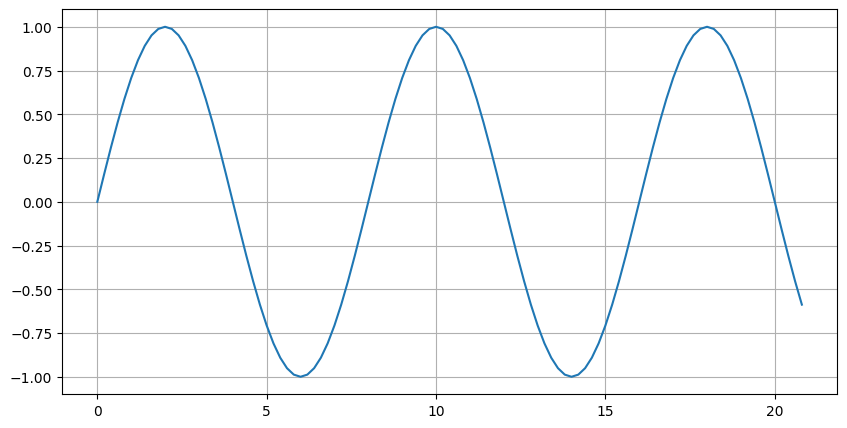

In [5]:
#Función SENO
import numpy as np
import matplotlib.pyplot as plt

def generar_sin(w0, theta0, n1, n2):
    """
     intervalo n1 ≤ n ≤ n2.

    Parámetros:
    w0: frecuencia
    theta0 :fase
    n1, n2 :intervalo de muestras

    da:
    n: vector t
    x: secuencia sin genereada
    """
    n = np.arange(n1, n2+1, 0.2)
    x = np.sin(w0 * n + theta0)
    return n, x

n,x  = generar_sin(np.pi/4,0,0,20)
plt.figure(10, figsize=(10,5))
plt.plot(n,x)
plt.grid(True)
plt.show()

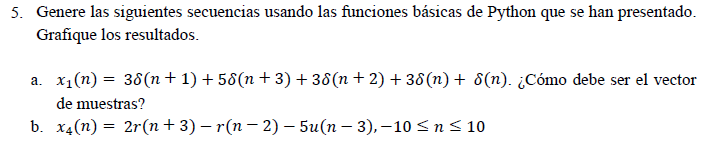

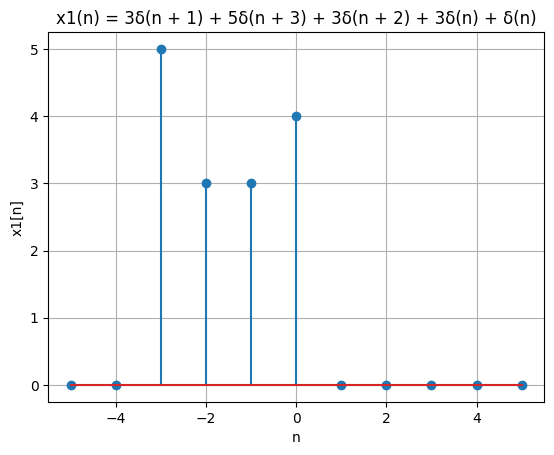

In [6]:
# punto 5.a)
#x1(n) = 3δ(n + 1) + 5δ(n + 3) + 3δ(n + 2) + 3δ(n) + δ(n).
n1=-5
n2=5
imp1, n= impseq(-1, n1,n2)
imp2, _= impseq(-3, n1,n2)
imp3, _= impseq(-2, n1,n2)
imp4, _= impseq(0, n1,n2)
imp5, _= impseq(0, n1,n2)

x1= 3*imp1 + 5*imp2 + 3*imp3 + 3*imp4 + imp5
plt.figure()
plt.title("x1(n) = 3δ(n + 1) + 5δ(n + 3) + 3δ(n + 2) + 3δ(n) + δ(n)")
plt.xlabel("n")
plt.ylabel("x1[n]")
plt.stem(n,x1)
plt.grid()


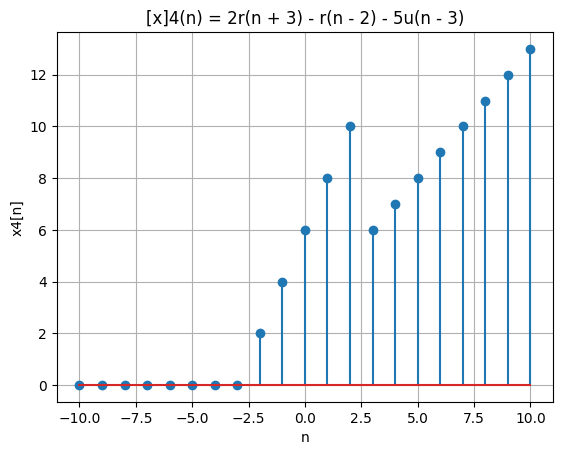

In [7]:
#Punto 5b
n1 = -10
n2 = 10
r1, n = rampa(-3, n1, n2)
r2, _  = rampa(2,  n1, n2)
u3, _  = escalon_unitario(3,n1, n2)


x4 = 2*r1 - r2 - 5*u3
plt.figure()
plt.title(r"[x]4(n) = 2r(n + 3) - r(n - 2) - 5u(n - 3)")
plt.xlabel("n")
plt.ylabel("x4[n]")
plt.stem(n,x4)
plt.grid()

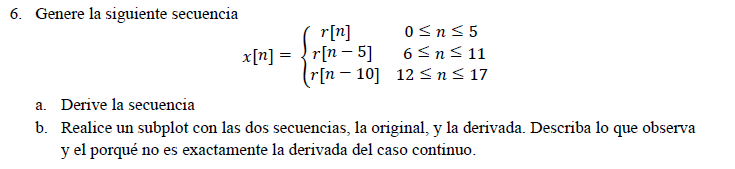


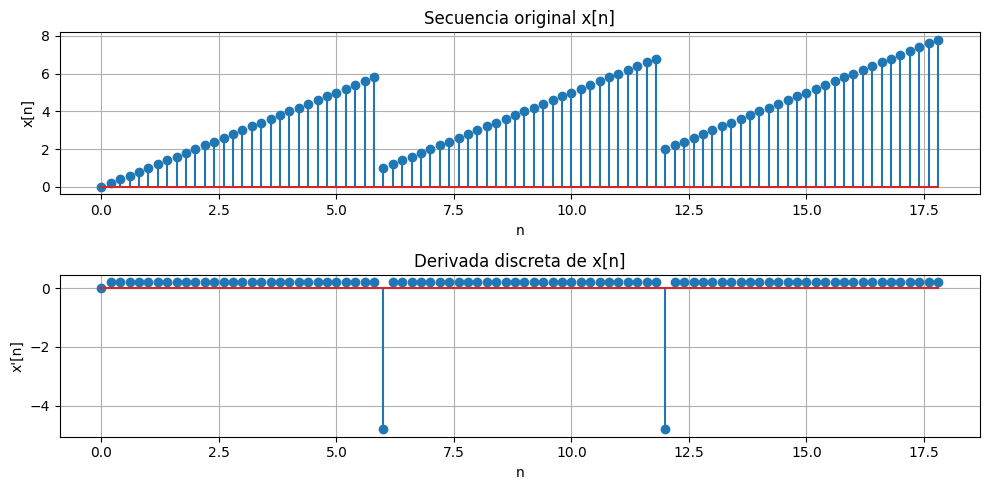

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def r(n):
    return np.where(n >= 0, n, 0)

def rampa(n0, n1, n2, m=1):
    n = np.arange(n1, n2 + 1, 0.2)
    x = (n >= n0) * m * (n - n0)
    return x, n

# Tramos
x1, n1 = rampa(0, 0, 5)      # r[n], entre 0 y 5
x2, n2 = rampa(5, 6, 11)     # r[n-5], entre 6 y 11
x3, n3 = rampa(10, 12, 17)   # r[n-10], entre 12 y 17

# Unir todos los tramos
n = np.concatenate([n1, n2, n3])
x = np.concatenate([x1, x2, x3])
dx = np.diff(x, prepend=0)  #derivada

plt.figure(figsize=(10,5))

plt.subplot(2,1,1)
plt.stem(n, x)
plt.title("Secuencia original x[n]")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)

plt.subplot(2,1,2)
plt.stem(n, dx)
plt.title("Derivada discreta de x[n]")
plt.xlabel("n")
plt.ylabel("x'[n]")
plt.grid(True)

plt.tight_layout()
plt.show()




*   La secuencia original muestra claramente tres rampas desplazadas.

* La derivada discreta resulta en tramos planos de valor 1, porque la pendiente de cada rampa es constante (igual a 1).

* En los puntos de transición entre tramos, aparecen saltos discretos



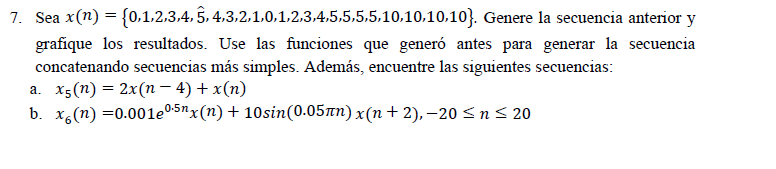

In [9]:
#Vamos a dar un rango de toda la funciòn x(n) con 23 elementos
n1, n2 = -5, 17

#Parte 1: rampa de -5 a -1
x1, n = rampa(-5,n1,n2)
x1 = x1 * ((n>=-5)&(n<=-1))

#Parte 2: impulso en n=0 con valor 5
d0, _ = impseq(0,n1,n2)
x2 = 5*d0

#Parte 3: rampa decreciente baja de 4 a 0, desde 1 hasta 5
r1, _ = rampa(1,n1,n2)
r2, _ = rampa(6,n1,n2)
x3 = 4 - (r1 - r2) # a 4 le resto la rampa porque quiero que empiece en 4
#se secciona el trazo de interés
x3 = x3 * ((n>=1)&(n<=5))


#Parte 4: rampa creciente de 1 a 4, desde n=6 hasta n=9
r3, _ = rampa(5,n1,n2)
r4, _ = rampa(9,n1,n2)
x4 = (r3 - r4)

#Parte 5: escalón en 5, desde n=10 hasta n=13
u11, _ = escalon_unitario(10,n1,n2)
u15, _ = escalon_unitario(14,n1,n2)
x5 = (u11-u15)

#Parte 6: escalón 10, desde n= 14 hasta n=17
u15, _ = escalon_unitario(14,n1,n2)
u19, _ = escalon_unitario(18,n1,n2)
x6 =6* (u15-u19) #No es clara la razòn de porque funciona la multiplicaciòn por 6 para que de el escalòn de 10

#Se concatenan los tramos
x = x1 + x2 + x3 + x4 + x5 + x6

plt.stem(n,x)
plt.title("Secuencia x(n) construida con funciones")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid()


ValueError: operands could not be broadcast together with shapes (115,) (23,) 

a. x5(n) = 2x(n − 4) + x(n)

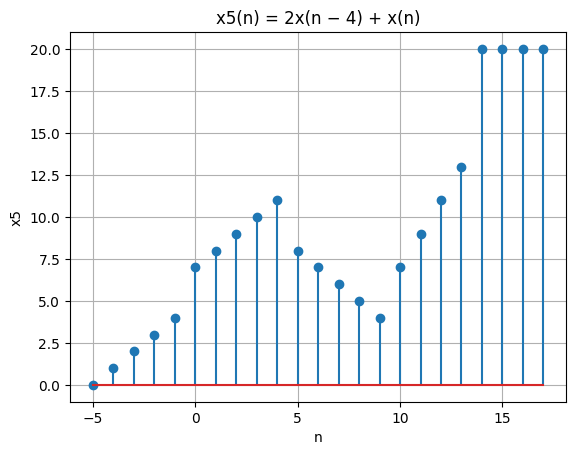

In [ ]:
#Hacemos la señal desplaza en -4, es decir 4 a la derecha
x_des = np.zeros_like(x) #hacemos un vector como el original x pero de ceros
x_des[4:] =  x[:-4] #aquí hacemos que apartir de la posición n=4

x5= (2*x_des) + x
plt.figure()
plt.stem(n,x5)

plt.title("x5(n) = 2x(n − 4) + x(n)")
plt.xlabel("n")
plt.ylabel("x5")
plt.grid()

b. x6(n) =0.001e0.5nx(n) + 10sin(0.05πn) x(n + 2), −20 ≤ n ≤ 20

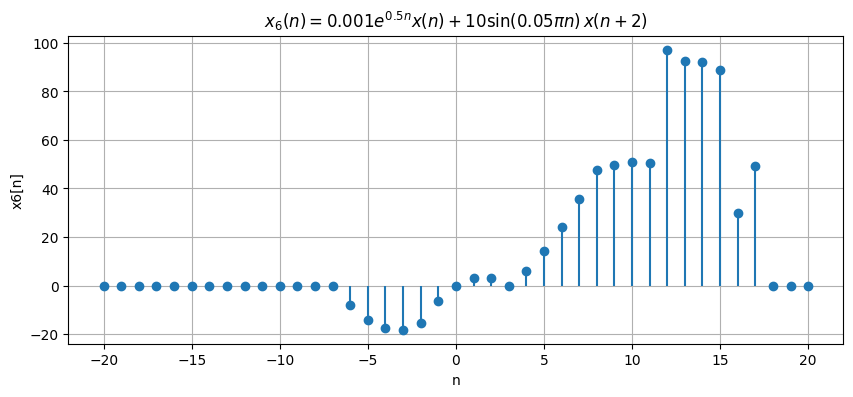

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Vamos a extender el rango ya el n original va de -5 hasta 17
n_ext = np.arange(-20, 21)   # -20 <= n <= 20
L = len(n_ext)
x_ext = np.zeros_like(n_ext, dtype=float)

for i, ni in enumerate(n): #Recorremos el vector n original para buscar en que posiciòn de nuestro nuevo vector con el rango -20 a 20 está el valor de n original, asì
                           #identificamos las posiciones donde existen valores del x original y lo agregamos al nuevo vector x extendido, asì el x_ext tendrà los valores
                           #del x original y en las demàs posiciones temdra ceros
    punt = np.where(n_ext == ni)[0]
    if len(punt) > 0:
        x_ext[punt[0]] = x[i]

#Exponencial
expo, _ = expc(-20, 20, 0.5)
parte1 = 0.001 * np.real(expo) * x_ext

#Senoidal
_, seno = generar_sin(0.05*np.pi, 0, -20, 20)

#Para desplazar la señal del seno
x_desp = np.zeros_like(x_ext) #Para guaradar la señal desplazada en 2
for i, ni in enumerate(n_ext):
    punt = np.where(n == ni+2)[0]   # buscar valor x(n+2) en el vector original
    if len(punt) > 0: #Si se encuentra ese valor, pues si existe
        x_desp[i] = x[punt[0]] #se agrega al vector x desplazado en la posiciòn i, en valor de x del original

parte2 = 10 * seno * x_desp

# Señal total
x6 = parte1 + parte2

# Gráfic0
plt.figure(figsize=(10,4))
plt.stem(n_ext, x6,basefmt=" ")
plt.title(r"$x_6(n) = 0.001e^{0.5n}x(n) + 10\sin(0.05\pi n)\,x(n+2)$")
plt.xlabel("n")
plt.ylabel("x6[n]")
plt.grid()

